In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
iris=datasets.load_iris()

In [3]:
iris_data=pd.DataFrame(iris.data)
iris_data.columns=iris.feature_names

In [4]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(iris_data)

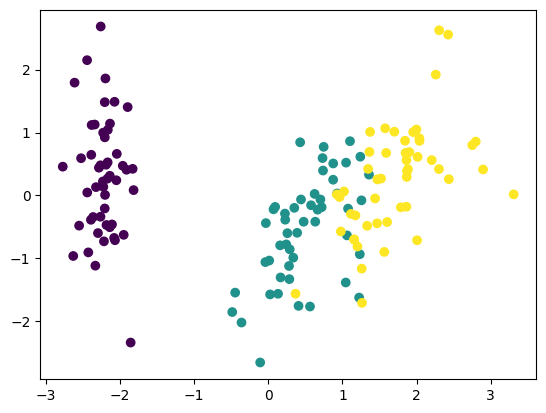

In [5]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_scaled=pca.fit_transform(X_scaled)
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)

Text(0, 0.5, 'Eucledian Distance')

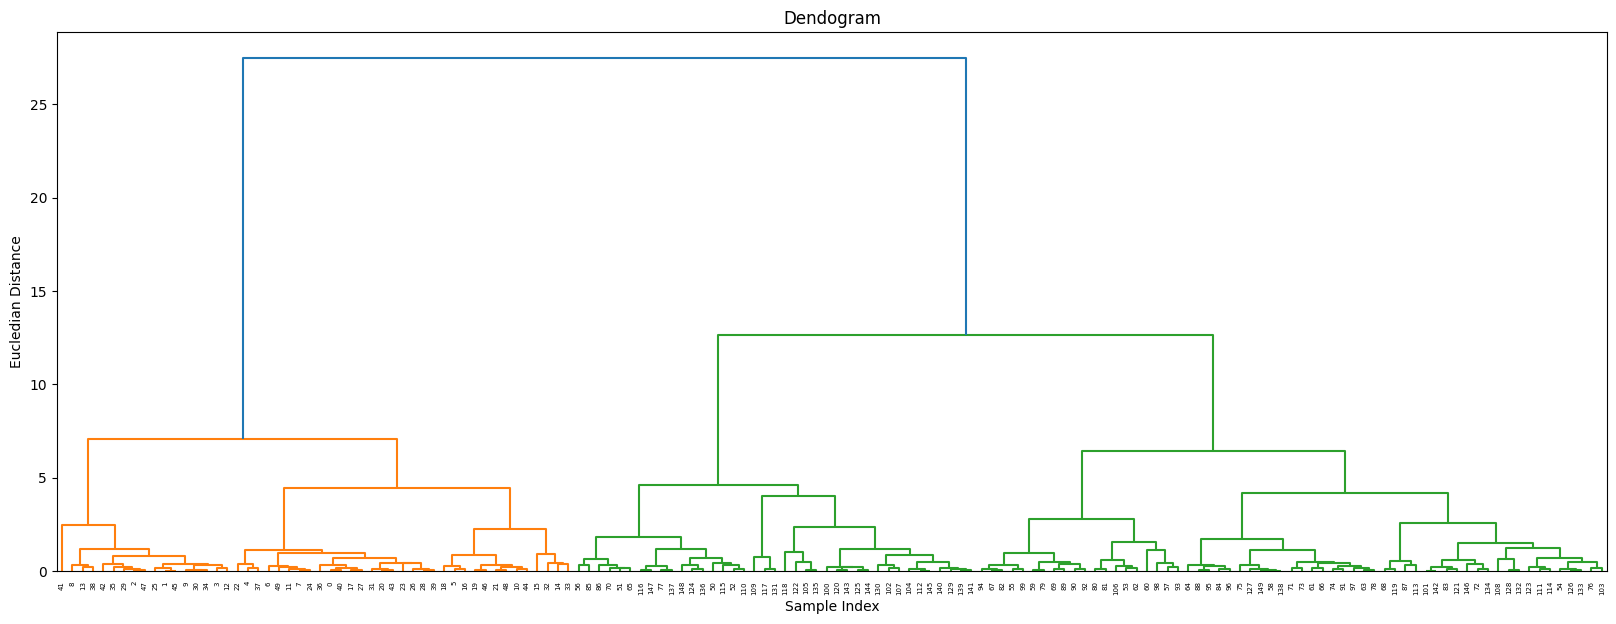

In [ ]:
import scipy.cluster.hierarchy as sc
##plot the dendogram
plt.figure(figsize=(20,7))
plt.title("Dendograms")

## create dendogram
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('Dendogram')
plt.xlabel('Sample Index')
plt.ylabel('Eucledian Distance')
# The 'method' parameter in sc.linkage() specifies the linkage algorithm used 
# to compute distances between clusters during hierarchical clustering.
# 'ward' method minimizes the variance within clusters by calculating the 
# distance as: sqrt( (|v|+|s|)/T * d(v,s)^2 + (|v|+|t|)/T * d(v,t)^2 - |v|/T * d(s,t)^2 )
# where T = |v|+|s|+|t|, making it robust to noise and similar to K-means.[web:1]

# Available linkage methods include:[web:1]
# - 'single': Minimum distance between closest points (nearest point algorithm) 
# - 'complete': Maximum distance between farthest points (farthest point algorithm)
# - 'average': Average distance between all pairs of points (UPGMA)
# - 'weighted': Weighted average of distances (WPGMA)
# - 'centroid': Euclidean distance between cluster centroids (UPGMC)
# - 'median': Median distance between centroids (WPGMC)
# - 'ward': Variance minimization (default for many implementations, robust to outliers)

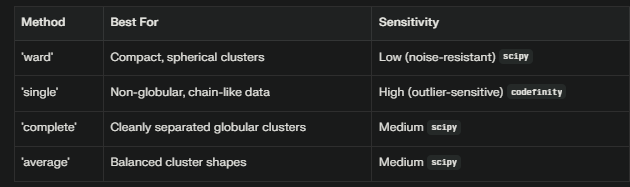

In [8]:
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=2,linkage='ward')
cluster.fit(pca_scaled)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


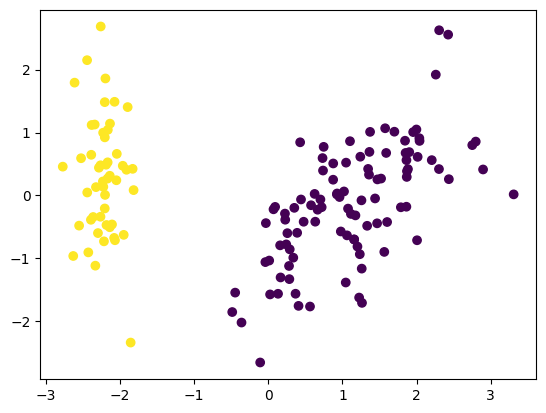

In [9]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)

In [11]:
from sklearn import cluster, datasets, mixture 
n_samples = 500
seed = 30
data = {
    "circles": datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
),
     "moons":datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed),
     "blobs": datasets.make_blobs(n_samples=n_samples, random_state=seed)
    
}

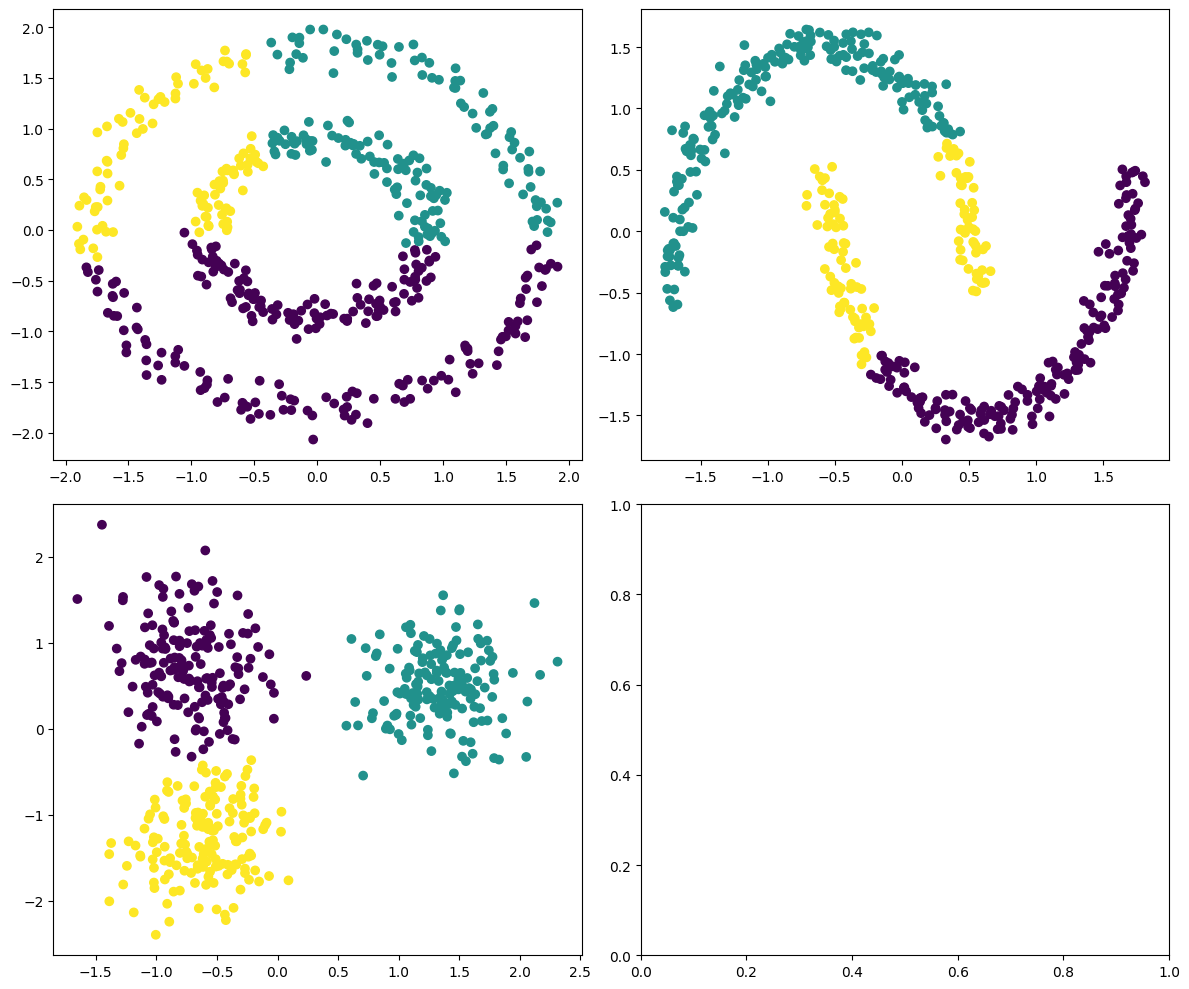

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create subplots - ONE plot with multiple panels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.ravel()  # Flatten for easy indexing

i = 0
for name, (X, y_true) in data.items():
    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # KMeans clustering
    agglo = AgglomerativeClustering(n_clusters=3,linkage='ward')
    y_pred = agglo.fit_predict(X_scaled)
    
    # Plot on subplot
    axes[i].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis')

    i += 1

plt.tight_layout()
plt.show()
